# EDA de transacciones bancarias para detección de fraude 💳

Este notebook fue **reorganizado y documentado** para que cada bloque tenga:

- **qué hace el código**
- **por qué se usa**
- **qué aporta cada gráfica**
- **cómo interpretar los resultados**

> **Nota:** el archivo original cargaba el dataset desde una ruta de Kaggle. Esa ruta se conserva, pero también se deja una alternativa local para que puedas adaptarlo fácilmente.

## 1. Importación de librerías y exploración del entorno

### ¿Qué hace este bloque?
Importa las librerías base para análisis de datos y revisa qué archivos existen en el entorno de Kaggle.

### ¿Por qué es importante?
Antes de analizar cualquier dataset, necesitamos:
- herramientas para cálculos numéricos (**NumPy**),
- manipulación tabular (**pandas**),
- y verificar dónde está almacenado el archivo para poder cargarlo sin errores.

### Explicación del código
- `import numpy as np`: importa NumPy y le asigna el alias `np`.
- `import pandas as pd`: importa pandas y le asigna el alias `pd`.
- `import os`: permite interactuar con carpetas y archivos del sistema.
- `os.walk('/kaggle/input')`: recorre recursivamente la carpeta de entrada de Kaggle.
- `print(os.path.join(dirname, filename))`: imprime la ruta completa de cada archivo encontrado.

### ¿Qué aporta este bloque al análisis?
No genera visualizaciones todavía, pero ayuda a garantizar que el dataset está accesible y que el entorno está listo para trabajar.

In [46]:
import numpy as np
import pandas as pd
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

## 2. Carga del dataset

### ¿Qué hace este bloque?
Lee el archivo CSV con las transacciones bancarias y lo guarda en un DataFrame llamado `df`.

### ¿Por qué se hace así?
`pandas.read_csv()` es la forma estándar de cargar archivos tabulares en Python.  
El DataFrame es la estructura central para limpiar, explorar, visualizar y modelar datos.

### Explicación del código
- `pd.read_csv(...)`: abre el archivo CSV.
- `df = ...`: guarda el resultado en la variable `df`.

### Recomendación de mejora
Conviene dejar una alternativa local en caso de que el notebook se ejecute fuera de Kaggle.

In [78]:
# 1. Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

print("Google Drive montado en '/content/drive'.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive montado en '/content/drive'.


In [79]:
# 2. Crear una carpeta en Google Drive para los datasets de Kaggle
!mkdir -p /content/drive/MyDrive/KaggleDatasets

print("Carpeta '/content/drive/MyDrive/KaggleDatasets' creada en Google Drive.")

Carpeta '/content/drive/MyDrive/KaggleDatasets' creada en Google Drive.


In [49]:
# 1. Instalar la librería Kaggle
!pip install kaggle

### 2. Sube tu archivo `kaggle.json`

Necesitas obtener tu `kaggle.json` de tu perfil de Kaggle (Cuenta -> Crear nuevo token API). Una vez descargado, arrastra este archivo a la sección de archivos de Colab (el icono de la carpeta en la barra lateral izquierda).

**Asegúrate de que el archivo `kaggle.json` esté en la raíz de tu entorno de Colab antes de ejecutar la siguiente celda.**

In [80]:
# 4. Mover kaggle.json desde Drive y establecer permisos
import os

# Crear la carpeta .kaggle si no existe
!mkdir -p ~/.kaggle

# Copiar el archivo kaggle.json desde Google Drive a la carpeta .kaggle
# Asumimos que el usuario lo subió a la raíz de su Google Drive
!cp /content/drive/MyDrive/kaggle.json ~/.kaggle/

# Establecer permisos para el archivo kaggle.json (requerido por Kaggle API)
!chmod 600 ~/.kaggle/kaggle.json

print("Configuración de Kaggle API completada.")

Configuración de Kaggle API completada.


In [81]:
# 5. Descargar el dataset a Google Drive
# El dataset es 'bank-transactions-dataset-for-fraud-detection' del usuario 'thuandao'
# Lo descargamos directamente a la carpeta KaggleDatasets en MyDrive
!kaggle datasets download -d thuandao/bank-transactions-dataset-for-fraud-detection -p /content/drive/MyDrive/KaggleDatasets

print("Dataset descargado a Google Drive.")

Dataset URL: https://www.kaggle.com/datasets/thuandao/bank-transactions-dataset-for-fraud-detection
License(s): apache-2.0
bank-transactions-dataset-for-fraud-detection.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset descargado a Google Drive.


In [82]:
# 6. Descomprimir el archivo zip desde Google Drive
import zipfile
import glob

# Ruta donde esperamos encontrar el archivo zip en Drive
drive_dataset_path = '/content/drive/MyDrive/KaggleDatasets/'

# Encontrar el archivo zip descargado (puede tener un nombre ligeramente diferente) en Drive
zip_files = glob.glob(os.path.join(drive_dataset_path, '*.zip'))

if zip_files:
    zip_file_path = zip_files[0]
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(drive_dataset_path) # Extraer en el directorio de Drive
    print(f"Archivo '{zip_file_path}' descomprimido en Google Drive.")
else:
    print(f"No se encontró ningún archivo zip en '{drive_dataset_path}' para descomprimir.")

Archivo '/content/drive/MyDrive/KaggleDatasets/bank-transactions-dataset-for-fraud-detection.zip' descomprimido en Google Drive.


### 6. Cargar el dataset en un DataFrame de pandas

Ahora que el archivo CSV ha sido descargado y descomprimido en el entorno de Colab, podemos cargarlo. El nombre del archivo CSV es `bank_transactions_data_2_augmented_clean_2.csv`.

In [83]:
# Cargar el dataset desde Google Drive
df = pd.read_csv('/content/drive/MyDrive/KaggleDatasets/bank_transactions_data_2_augmented_clean_2.csv')

print("Dataset cargado en 'df' desde Google Drive.")

Dataset cargado en 'df' desde Google Drive.


In [84]:
# Mostrar las primeras filas para verificar la carga
display(df.head())

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,TX000001,AC00128,14.09,4/11/2023 16:29,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21
1,TX000002,AC00455,376.24,6/27/2023 16:44,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91
2,TX000003,AC00019,126.29,7/10/2023 18:16,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35
3,TX000004,AC00070,184.50,5/5/2023 16:32,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06
4,TX000005,AC00411,13.45,10/16/2023 17:51,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40


## 3. Vista inicial del dataset

### ¿Qué hace este bloque?
Muestra las primeras filas del DataFrame.

### ¿Por qué es importante?
Permite validar rápidamente:
- si la carga fue exitosa,
- cómo se llaman las columnas,
- qué tipo de valores tienen,
- y si hay datos que parecen inconsistentes a simple vista.

### Explicación del código
- `df.head()`: muestra las primeras 5 filas del DataFrame.

### ¿Qué deberías observar aquí?
- nombres de columnas como `TransactionAmount`, `TransactionType`, `Channel`, `CustomerAge`, etc.
- valores numéricos y categóricos,
- posibles campos útiles para detección de fraude.

In [85]:
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,TX000001,AC00128,14.09,4/11/2023 16:29,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21
1,TX000002,AC00455,376.24,6/27/2023 16:44,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91
2,TX000003,AC00019,126.29,7/10/2023 18:16,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35
3,TX000004,AC00070,184.50,5/5/2023 16:32,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06
4,TX000005,AC00411,13.45,10/16/2023 17:51,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40


## 4. Diagnóstico rápido de estructura del dataset

### ¿Qué hace este bloque?
Agrega una revisión inicial de dimensiones, tipos de datos, nulos y estadísticas descriptivas.

### ¿Por qué se añade?
El notebook original pasaba directo a las gráficas.  
Antes de visualizar, es recomendable entender la estructura del dataset para decidir **qué tipo de gráfica corresponde a cada columna**.

### ¿Qué aporta?
- `shape`: tamaño del dataset.
- `info()`: tipos de datos y valores no nulos.
- `isna().sum()`: conteo de faltantes.
- `describe()`: resumen estadístico de variables numéricas.
- `describe(include='object')`: resumen de variables categóricas.

In [86]:
print("Dimensiones del dataset:", df.shape)
print("\nTipos de datos:")
df.info()

print("\nValores nulos por columna:")
print(df.isna().sum())

print("\nResumen estadístico de variables numéricas:")
display(df.describe())

print("\nResumen de variables categóricas:")
display(df.describe(include='object'))

Dimensiones del dataset: (50000, 15)

Tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   TransactionID        50000 non-null  object 
 1   AccountID            50000 non-null  object 
 2   TransactionAmount    50000 non-null  float64
 3   TransactionDate      50000 non-null  object 
 4   TransactionType      50000 non-null  object 
 5   Location             50000 non-null  object 
 6   DeviceID             50000 non-null  object 
 7   IP Address           50000 non-null  object 
 8   MerchantID           50000 non-null  object 
 9   Channel              50000 non-null  object 
 10  CustomerAge          50000 non-null  int64  
 11  CustomerOccupation   50000 non-null  object 
 12  TransactionDuration  50000 non-null  int64  
 13  LoginAttempts        50000 non-null  int64  
 14  AccountBalance       50000 non-n

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000
mean,297.872214,44.647600,118.965320,1.12684,5122.738301
std,292.818888,17.800293,70.000681,0.60936,3904.266887
min,0.240000,18.000000,10.000000,1.00000,101.250000
25%,82.897500,27.000000,63.000000,1.00000,1508.720000
50%,209.355000,45.000000,111.000000,1.00000,4735.410000
75%,409.625000,59.000000,161.000000,1.00000,7713.670000
max,2060.590000,80.000000,300.000000,5.00000,14977.990000



Resumen de variables categóricas:


,TransactionID,AccountID,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerOccupation
count,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000
unique,50000,495,6373,2,43,681,592,100,3,4
top,TX049984,AC00363,6/12/2021,Debit,Fort Worth,D000548,200.136.146.93,M026,Branch,Student
freq,1,249,35,38747,1396,196,261,940,17278,13059


## 5. Librerías de visualización y configuración estética

### ¿Qué hace este bloque?
Importa `matplotlib` y `seaborn`, y define un estilo visual base.

### ¿Por qué se usan estas librerías?
- **Matplotlib** ofrece control total sobre gráficos.
- **Seaborn** simplifica la creación de visualizaciones estadísticas y mejora la estética.

### Explicación del código
- `import matplotlib.pyplot as plt`: módulo principal para graficar.
- `import seaborn as sns`: biblioteca de gráficos estadísticos.
- `sns.set_style("whitegrid")`: agrega una cuadrícula ligera para facilitar la lectura.

### ¿Qué aporta?
Una visualización clara mejora la interpretación y ayuda a detectar patrones, anomalías y posibles señales de fraude.

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## Distribución de `TransactionAmount`

### ¿Por qué esta gráfica?
`TransactionAmount` es una variable numérica continua, por eso se usa un **histograma**.  
Este tipo de gráfica permite ver:
- concentración de montos,
- sesgo hacia valores pequeños o grandes,
- presencia de colas largas,
- y posibles valores atípicos.

### ¿Por qué también se usa `kde=True`?
La curva KDE agrega una estimación suave de la densidad, útil para entender la forma de la distribución.

### ¿Qué podría indicar en fraude?
Montos inusualmente altos o distribuciones con colas extremas pueden ser señales relevantes para futuras reglas o modelos.

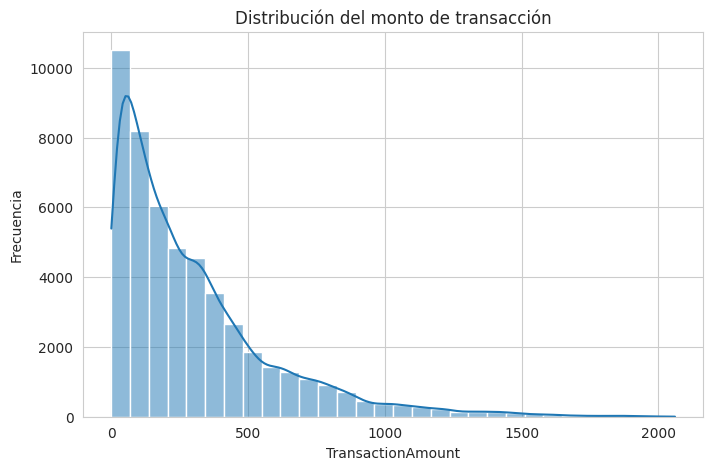

In [88]:
plt.figure(figsize=(8,5))
sns.histplot(df['TransactionAmount'], bins=30, kde=True)
plt.title('Distribución del monto de transacción')
plt.xlabel('TransactionAmount')
plt.ylabel('Frecuencia')
plt.show()

## Conteo de `TransactionType`

### ¿Por qué esta gráfica?
`TransactionType` es una variable categórica, por eso se utiliza un **countplot**.  
Sirve para comparar cuántas transacciones hay de cada tipo.

### ¿Qué aporta?
Permite identificar:
- categorías dominantes,
- categorías raras,
- y posibles desbalances.

### Relevancia para fraude
Ciertos tipos de transacción pueden estar más asociados a eventos sospechosos que otros.

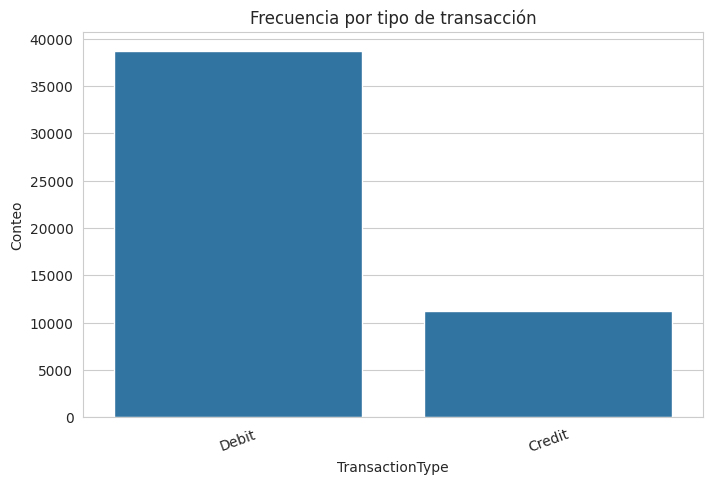

In [89]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='TransactionType')
plt.title('Frecuencia por tipo de transacción')
plt.xlabel('TransactionType')
plt.ylabel('Conteo')
plt.xticks(rotation=20)
plt.show()

## Conteo de `Channel`

### ¿Por qué esta gráfica?
`Channel` también es categórica, así que un **countplot** es apropiado.

### ¿Qué permite analizar?
Muestra la distribución de operaciones por canal, por ejemplo:
- móvil,
- web,
- sucursal,
- cajero, etc.

### Relevancia para fraude
Algunos canales suelen ser más vulnerables o más usados en intentos de fraude.

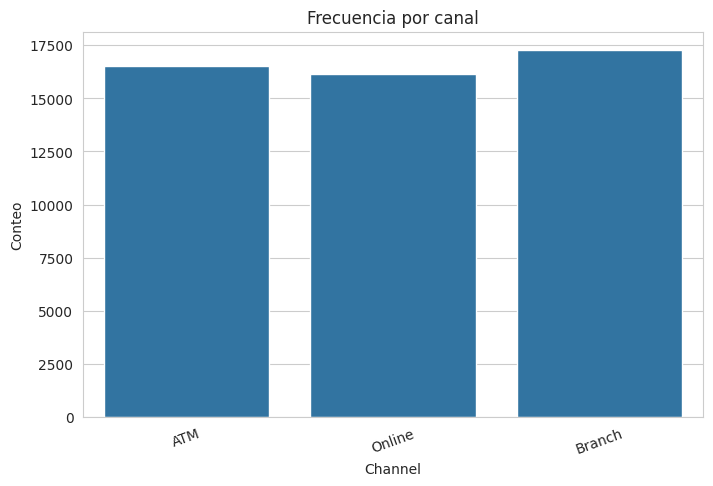

In [90]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Channel')
plt.title('Frecuencia por canal')
plt.xlabel('Channel')
plt.ylabel('Conteo')
plt.xticks(rotation=20)
plt.show()

## Distribución de `CustomerOccupation`

### ¿Por qué esta gráfica?
`CustomerOccupation` es categórica y puede tener muchas categorías.  
Por eso se usa un **countplot horizontal** (`y=`), ya que mejora la legibilidad cuando los nombres son extensos o hay varias categorías.

### ¿Qué aporta?
Permite observar si ciertas ocupaciones predominan en el dataset.

### Relevancia para fraude
No implica causalidad, pero ayuda a perfilar la composición de clientes y detectar grupos sobrerrepresentados.

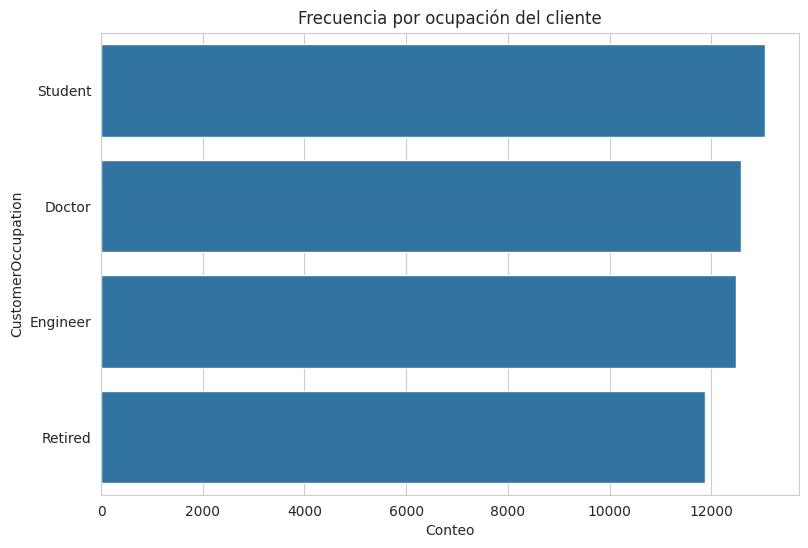

In [91]:
plt.figure(figsize=(9,6))
sns.countplot(data=df, y='CustomerOccupation', order=df['CustomerOccupation'].value_counts().index)
plt.title('Frecuencia por ocupación del cliente')
plt.xlabel('Conteo')
plt.ylabel('CustomerOccupation')
plt.show()

## Distribución de `CustomerAge`

### ¿Por qué esta gráfica?
`CustomerAge` es una variable numérica, así que el **histograma** permite analizar cómo se distribuyen las edades.

### ¿Qué aporta?
Ayuda a ver:
- rangos de edad dominantes,
- asimetría,
- concentración,
- y edades atípicas.

### Relevancia para fraude
Algunos patrones anómalos pueden concentrarse en determinados segmentos etarios.

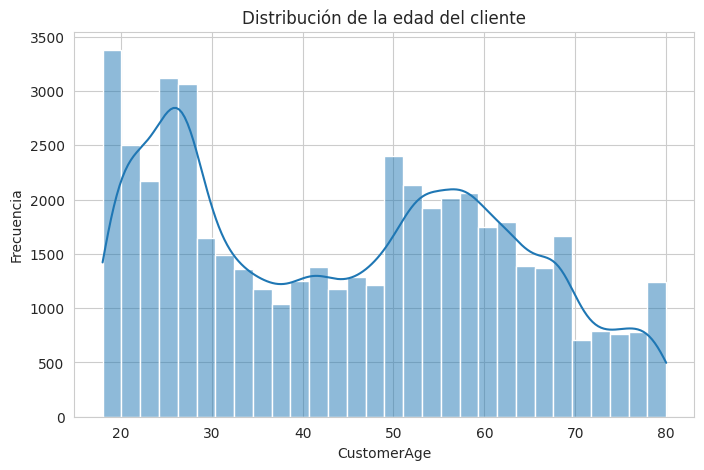

In [92]:
plt.figure(figsize=(8,5))
sns.histplot(df['CustomerAge'], bins=30, kde=True)
plt.title('Distribución de la edad del cliente')
plt.xlabel('CustomerAge')
plt.ylabel('Frecuencia')
plt.show()

## Distribución de `TransactionDuration`

### ¿Por qué esta gráfica?
`TransactionDuration` es numérica continua.  
Un histograma permite observar si la mayoría de transacciones duran poco o si existen duraciones anómalas.

### Relevancia para fraude
Duraciones extremadamente cortas o largas pueden ser indicios de automatización, errores o comportamientos inusuales.

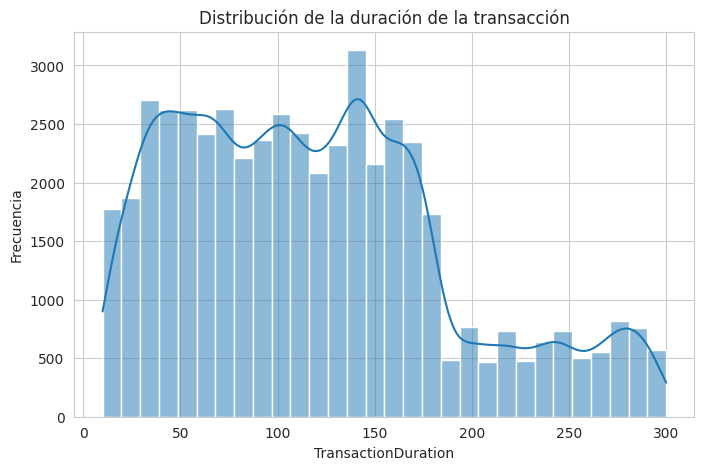

In [93]:
plt.figure(figsize=(8,5))
sns.histplot(df['TransactionDuration'], bins=30, kde=True)
plt.title('Distribución de la duración de la transacción')
plt.xlabel('TransactionDuration')
plt.ylabel('Frecuencia')
plt.show()

## Conteo de `LoginAttempts`

### ¿Por qué esta gráfica?
`LoginAttempts` puede tratarse como una variable discreta/ordinal.  
El **countplot** permite comparar cuántas transacciones ocurrieron con 1, 2, 3 o más intentos.

### Relevancia para fraude
Un número alto de intentos de acceso puede sugerir comportamiento sospechoso o fricción de autenticación.

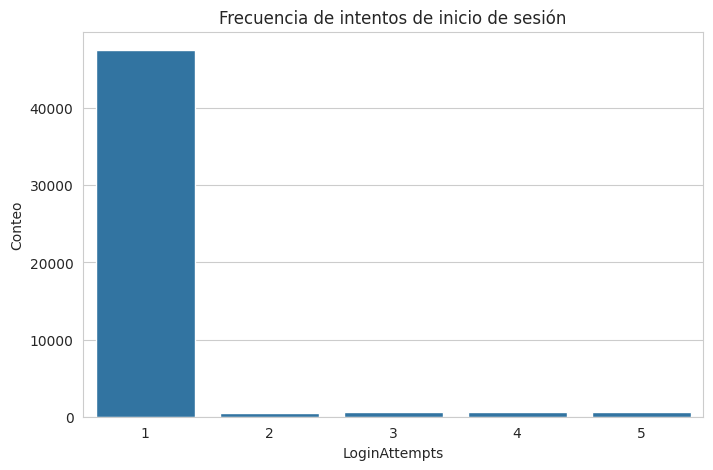

In [94]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='LoginAttempts')
plt.title('Frecuencia de intentos de inicio de sesión')
plt.xlabel('LoginAttempts')
plt.ylabel('Conteo')
plt.show()

## Top 10 de `Location`

### ¿Por qué esta gráfica?
`Location` es categórica y puede tener muchas modalidades.  
Mostrar todas podría saturar la visualización, por eso se selecciona el **top 10**.

### ¿Qué aporta?
Permite ver qué ubicaciones concentran más transacciones.

### Relevancia para fraude
Las ubicaciones más frecuentes sirven como referencia; luego se pueden comparar contra ubicaciones raras o inesperadas.

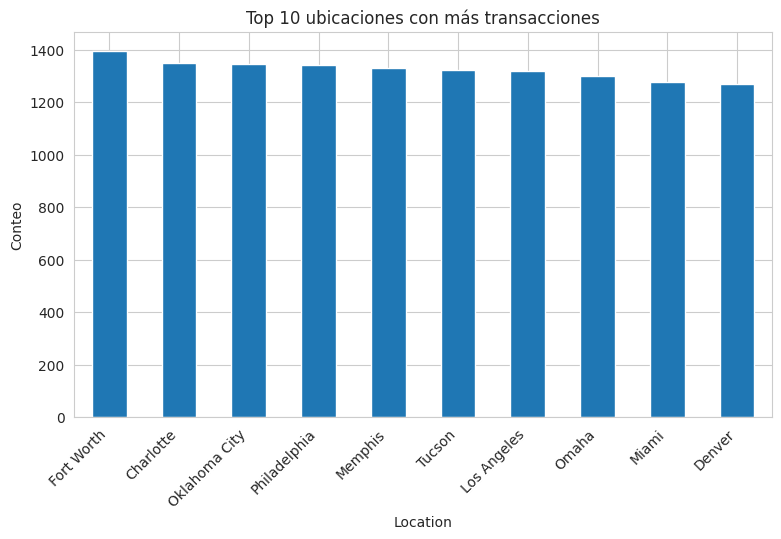

In [95]:
plt.figure(figsize=(9,5))
df['Location'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 ubicaciones con más transacciones')
plt.xlabel('Location')
plt.ylabel('Conteo')
plt.xticks(rotation=45, ha='right')
plt.show()

## `Channel` vs `TransactionType`

### ¿Por qué esta gráfica?
Aquí se cruzan **dos variables categóricas**, así que un **countplot con `hue`** es adecuado.

### ¿Qué aporta?
Permite responder preguntas como:
- ¿qué tipo de transacción predomina en cada canal?
- ¿hay combinaciones poco comunes?

### Relevancia para fraude
Las combinaciones atípicas entre canal y tipo pueden ser señales útiles para segmentar riesgo.

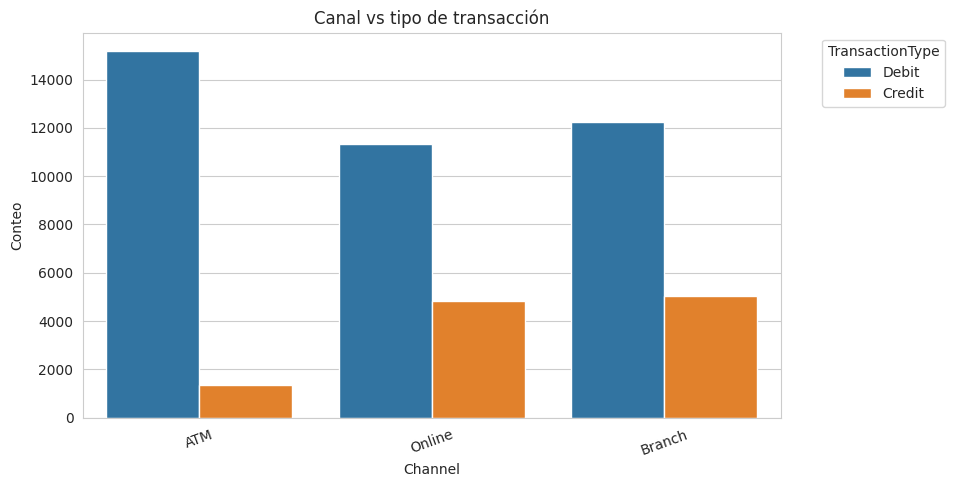

In [96]:
plt.figure(figsize=(9,5))
sns.countplot(data=df, x='Channel', hue='TransactionType')
plt.title('Canal vs tipo de transacción')
plt.xlabel('Channel')
plt.ylabel('Conteo')
plt.xticks(rotation=20)
plt.legend(title='TransactionType', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## `CustomerAge` vs `TransactionAmount`

### ¿Por qué esta gráfica?
Se usan **dos variables numéricas**, por eso corresponde un **scatterplot**.

### ¿Qué aporta?
Permite ver si existe relación entre edad y monto:
- tendencia ascendente o descendente,
- dispersión,
- clusters,
- outliers.

### Relevancia para fraude
No siempre habrá correlación, pero los puntos aislados pueden representar casos dignos de revisión.

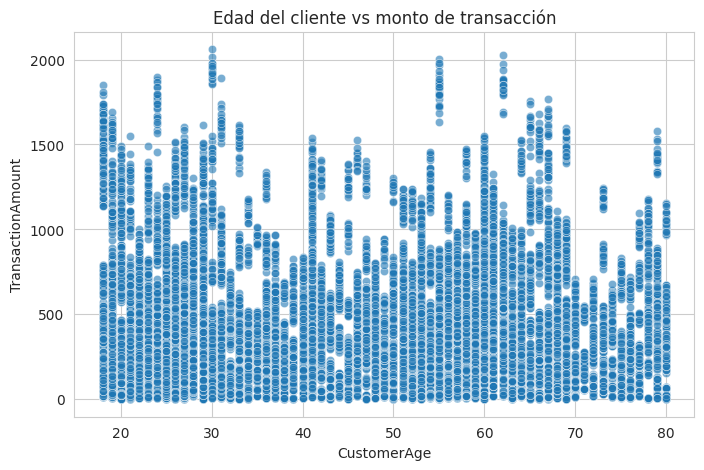

In [97]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='CustomerAge', y='TransactionAmount', alpha=0.6)
plt.title('Edad del cliente vs monto de transacción')
plt.xlabel('CustomerAge')
plt.ylabel('TransactionAmount')
plt.show()

## `CustomerAge` vs `AccountBalance`

### ¿Por qué esta gráfica?
De nuevo se comparan dos variables numéricas, así que el **scatterplot** ayuda a detectar relación o ausencia de ella.

### ¿Qué aporta?
Muestra si ciertos rangos de edad se asocian con balances de cuenta más altos o más bajos.

### Relevancia para fraude
Ayuda a perfilar comportamiento financiero esperado y a detectar operaciones fuera de contexto.

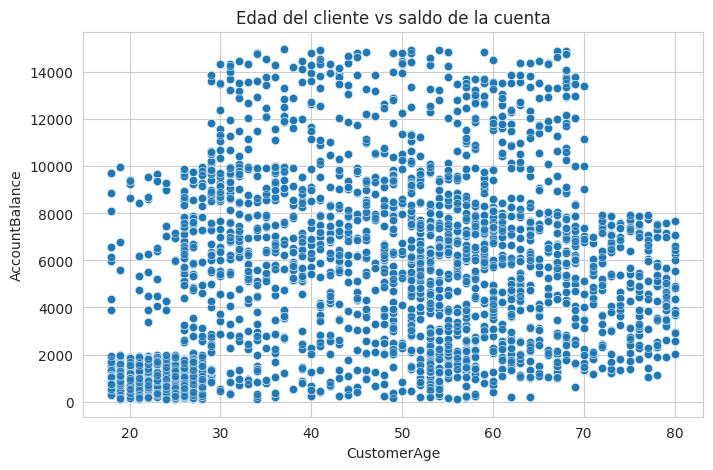

In [98]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='CustomerAge', y='AccountBalance', alpha=0.6)
plt.title('Edad del cliente vs saldo de la cuenta')
plt.xlabel('CustomerAge')
plt.ylabel('AccountBalance')
plt.show()

## `TransactionAmount` vs `AccountBalance`

### ¿Por qué esta gráfica?
Ambas variables son numéricas. El **scatterplot** permite ver la relación entre el monto transaccionado y el saldo disponible.

### ¿Qué aporta?
Puede revelar:
- si los montos guardan proporción con el saldo,
- si existen operaciones muy altas sobre saldos bajos,
- o concentraciones sospechosas.

### Relevancia para fraude
Una transacción muy alta respecto al saldo puede ser un caso relevante para análisis posterior.

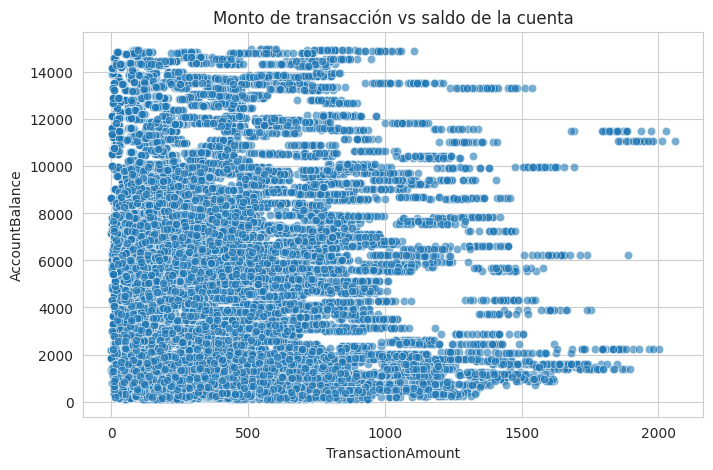

In [99]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='TransactionAmount', y='AccountBalance', alpha=0.6)
plt.title('Monto de transacción vs saldo de la cuenta')
plt.xlabel('TransactionAmount')
plt.ylabel('AccountBalance')
plt.show()

## Boxplot de `TransactionAmount` por `Channel`

### ¿Por qué esta gráfica?
Aquí se compara una variable numérica (`TransactionAmount`) entre grupos categóricos (`Channel`).  
El **boxplot** es ideal para esto porque resume:
- mediana,
- cuartiles,
- dispersión,
- y valores atípicos.

### ¿Qué aporta?
Permite saber si ciertos canales manejan montos más altos o más variables que otros.

### Relevancia para fraude
Los outliers por canal pueden ser especialmente útiles en reglas de monitoreo.

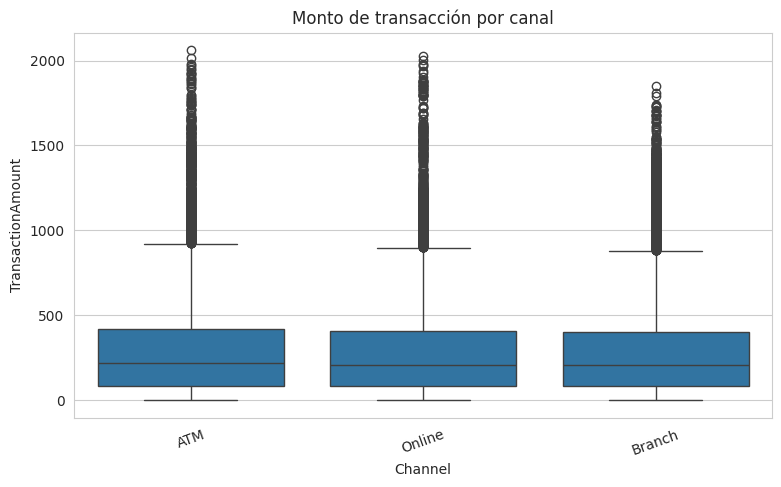

In [100]:
plt.figure(figsize=(9,5))
sns.boxplot(data=df, x='Channel', y='TransactionAmount')
plt.title('Monto de transacción por canal')
plt.xlabel('Channel')
plt.ylabel('TransactionAmount')
plt.xticks(rotation=20)
plt.show()

## Boxplot de `TransactionAmount` por `TransactionType`

### ¿Por qué esta gráfica?
Compara el monto según cada tipo de transacción.

### ¿Qué aporta?
Sirve para detectar:
- qué tipos suelen mover más dinero,
- cuáles tienen mayor dispersión,
- y dónde aparecen más outliers.

### Relevancia para fraude
Algunos tipos podrían presentar una cola de valores extremos mayor que otros.

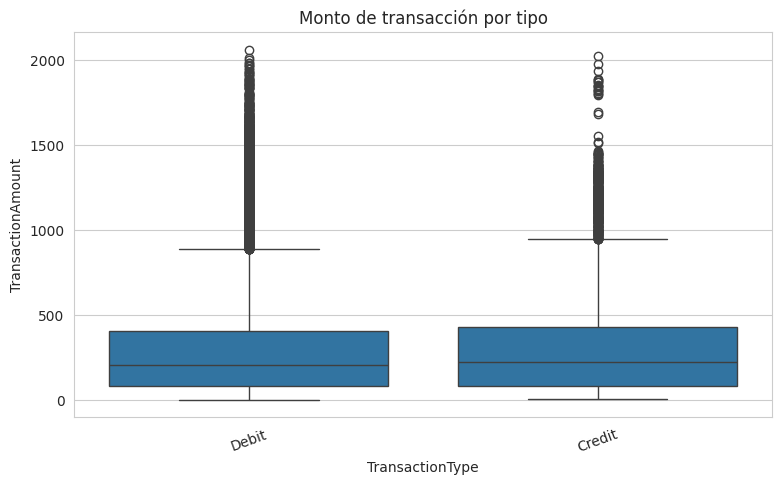

In [101]:
plt.figure(figsize=(9,5))
sns.boxplot(data=df, x='TransactionType', y='TransactionAmount')
plt.title('Monto de transacción por tipo')
plt.xlabel('TransactionType')
plt.ylabel('TransactionAmount')
plt.xticks(rotation=20)
plt.show()

## Boxplot de `CustomerAge` por `Channel`

### ¿Por qué esta gráfica?
Compara una variable numérica (`CustomerAge`) entre categorías (`Channel`).

### ¿Qué aporta?
Permite observar si ciertos canales son más usados por ciertos grupos de edad.

### Relevancia para fraude
Puede servir para identificar combinaciones demográficas poco habituales.

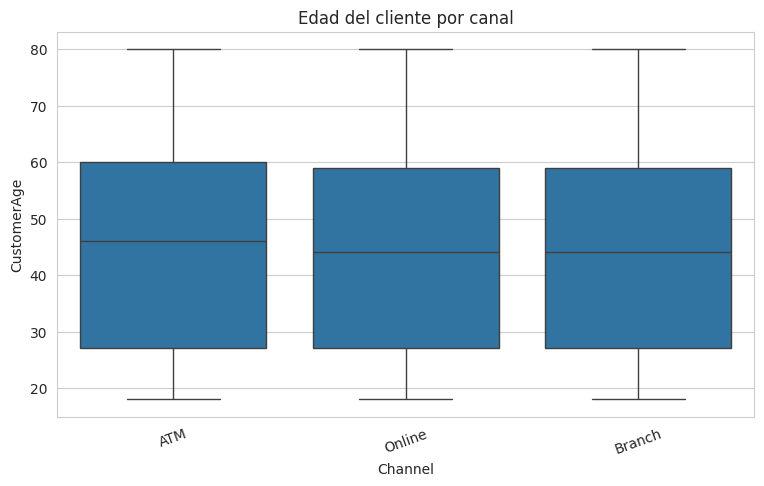

In [102]:
plt.figure(figsize=(9,5))
sns.boxplot(data=df, x='Channel', y='CustomerAge')
plt.title('Edad del cliente por canal')
plt.xlabel('Channel')
plt.ylabel('CustomerAge')
plt.xticks(rotation=20)
plt.show()

## `TransactionDuration` vs `TransactionAmount`

### ¿Por qué esta gráfica?
Compara dos variables numéricas para evaluar si existe alguna asociación entre la duración y el monto.

### ¿Qué aporta?
Ayuda a detectar:
- tendencias,
- grupos diferenciados,
- transacciones lentas con montos altos,
- o rápidas con montos extremos.

### Relevancia para fraude
La combinación entre tiempo de ejecución y monto puede aportar señales operativas importantes.

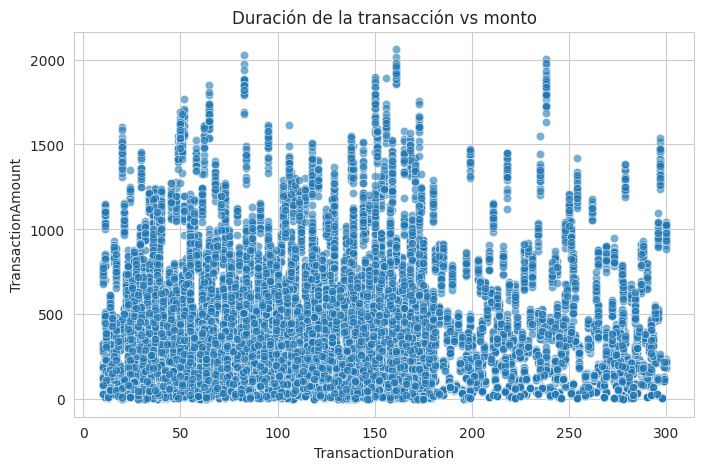

In [103]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='TransactionDuration', y='TransactionAmount', alpha=0.6)
plt.title('Duración de la transacción vs monto')
plt.xlabel('TransactionDuration')
plt.ylabel('TransactionAmount')
plt.show()

## Boxplot de `TransactionAmount` por `LoginAttempts`

### ¿Por qué esta gráfica?
Se compara el monto entre grupos definidos por cantidad de intentos de inicio de sesión.

### ¿Qué aporta?
Permite evaluar si a mayor número de intentos también aparecen montos más altos o más dispersos.

### Relevancia para fraude
Esta es una visualización valiosa porque conecta autenticación con comportamiento financiero.

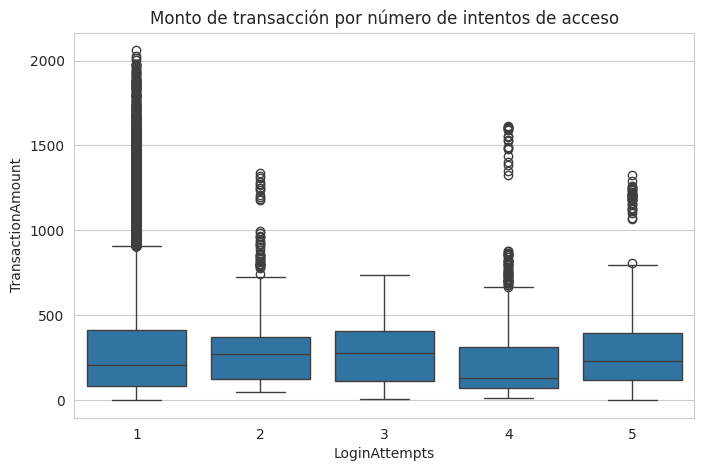

In [104]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='LoginAttempts', y='TransactionAmount')
plt.title('Monto de transacción por número de intentos de acceso')
plt.xlabel('LoginAttempts')
plt.ylabel('TransactionAmount')
plt.show()

## `LoginAttempts` vs `Channel`

### ¿Por qué esta gráfica?
Cruza dos variables categóricas/discretas.

### ¿Qué aporta?
Muestra si ciertos canales concentran más eventos con múltiples intentos de inicio de sesión.

### Relevancia para fraude
Es útil para detectar fricción o riesgo operativo por canal.

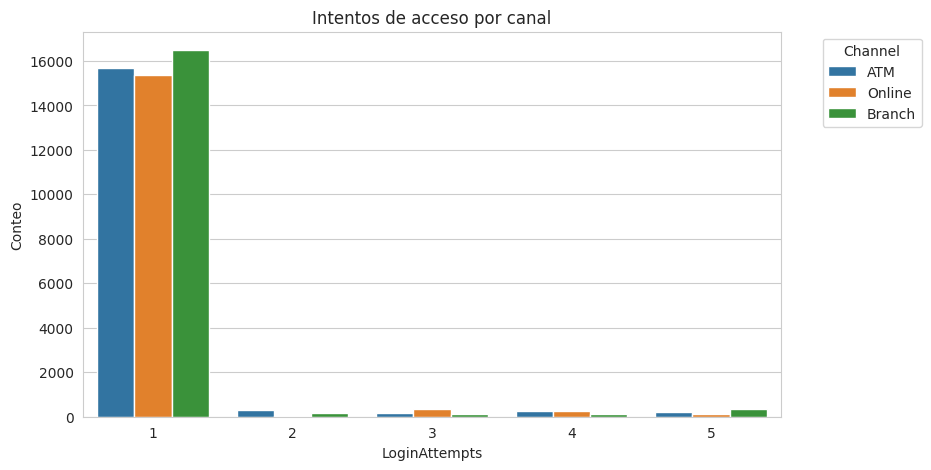

In [105]:
plt.figure(figsize=(9,5))
sns.countplot(data=df, x='LoginAttempts', hue='Channel')
plt.title('Intentos de acceso por canal')
plt.xlabel('LoginAttempts')
plt.ylabel('Conteo')
plt.legend(title='Channel', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Mapa de calor de correlación

### ¿Por qué esta gráfica?
Cuando existen varias variables numéricas, el **heatmap de correlación** ayuda a resumir relaciones lineales entre ellas.

### Explicación del código
- `df.select_dtypes(include=['int64','float64'])`: selecciona columnas numéricas.
- `.corr()`: calcula la matriz de correlación.
- `sns.heatmap(..., annot=True)`: dibuja el mapa y muestra los coeficientes.

### ¿Qué aporta?
Permite detectar:
- relaciones fuertes positivas,
- relaciones negativas,
- y variables posiblemente redundantes.

### Relevancia para fraude
En etapas posteriores puede ayudar a selección de variables o detección de dependencia entre atributos.

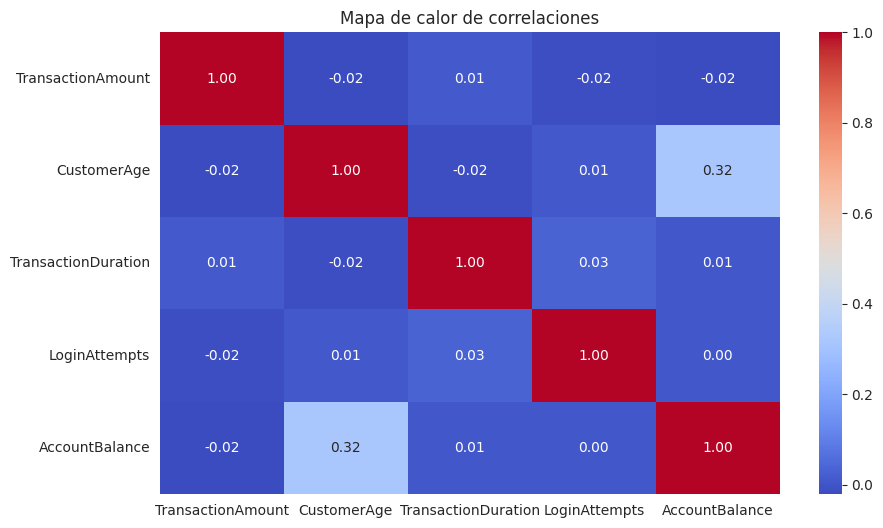

In [106]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Mapa de calor de correlaciones')
plt.show()

## Top 10 de `MerchantID`

### ¿Por qué esta gráfica?
`MerchantID` es categórica de alta cardinalidad.  
Mostrar todos los comercios podría ser ilegible, así que el **top 10** resume los más frecuentes.

### ¿Qué aporta?
Permite identificar los merchants con mayor volumen de transacciones.

### Relevancia para fraude
En análisis de fraude, la frecuencia por merchant es clave para establecer patrones normales y detectar desviaciones.

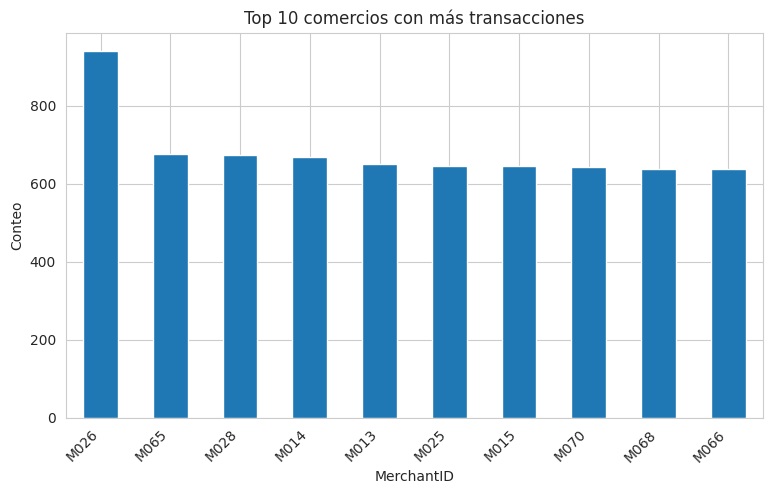

In [107]:
plt.figure(figsize=(9,5))
df['MerchantID'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 comercios con más transacciones')
plt.xlabel('MerchantID')
plt.ylabel('Conteo')
plt.xticks(rotation=45, ha='right')
plt.show()

## 6. Conclusiones metodológicas del notebook mejorado

### Mejoras incorporadas
Este notebook fue mejorado en cuatro frentes:

1. **Separación de gráficas por bloques**  
   En lugar de 20 gráficos dentro de una sola figura, ahora cada visualización queda aislada y es más fácil de interpretar.

2. **Explicación de cada línea o bloque de código**  
   Se explica qué hace el código y por qué se utiliza esa instrucción.

3. **Justificación de la elección de cada tipo de gráfica**  
   Cada visualización responde al tipo de variable:
   - numérica → histograma / scatter / boxplot
   - categórica → countplot / barras
   - numérica vs categórica → boxplot
   - numérica vs numérica → scatterplot
   - varias numéricas → heatmap de correlación

4. **Enfoque analítico orientado a fraude**
   Cada gráfica se conecta con preguntas de negocio y posibles señales de comportamiento anómalo.

### Recomendaciones adicionales
Como siguiente mejora, sería ideal agregar:
- análisis de valores nulos,
- análisis de outliers con IQR o z-score,
- comparación entre transacciones normales y fraudulentas si existe una variable objetivo,
- y un resumen final automático con hallazgos clave.

In [111]:
# Descargar el dataset original sin preprocesamiento desde Google Drive
import os
from google.colab import files

original_dataset_path = '/content/drive/MyDrive/KaggleDatasets/bank_transactions_data_2_augmented_clean_2.csv'
output_filename_raw = 'bank_transactions_raw.csv'

# Copiar el archivo original a un nombre local en el entorno de Colab para la descarga
!cp "{original_dataset_path}" "{output_filename_raw}"

print(f"Preparando para descargar '{output_filename_raw}' desde Google Drive.")

files.download(output_filename_raw)

print(f"DataFrame original '{output_filename_raw}' guardado y listo para descargar.")

Preparando para descargar 'bank_transactions_raw.csv' desde Google Drive.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

DataFrame original 'bank_transactions_raw.csv' guardado y listo para descargar.


In [110]:
# Guardar el DataFrame a un archivo CSV en el entorno de Colab
output_filename = 'bank_transactions_processed.csv'
df.to_csv(output_filename, index=False)

# Proporcionar un enlace de descarga al usuario
from google.colab import files
files.download(output_filename)

print(f"DataFrame '{output_filename}' guardado y listo para descargar.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

DataFrame 'bank_transactions_processed.csv' guardado y listo para descargar.


## Análisis de Outliers (Valores Atípicos) con IQR

### ¿Qué hace este bloque?
Este bloque identifica y visualiza los outliers (valores atípicos) en las columnas numéricas del DataFrame utilizando el método del Rango Intercuartílico (IQR). Un outlier es un punto de datos que se encuentra a una distancia inusual de otros puntos de datos.

### ¿Por qué es importante?
Los outliers pueden ser errores de entrada de datos, mediciones raras pero válidas, o **eventos de particular interés en la detección de fraude** (como transacciones inusualmente grandes o pequeñas). Entender su presencia y distribución es crucial para decidir si se deben tratar (eliminar, transformar o mantener) en el análisis o en futuros modelos.

### Explicación del código
- `numeric_df = df.select_dtypes(include=['int64', 'float64'])`: Selecciona solo las columnas numéricas para el análisis.
- **Método IQR:**
    - `Q1 = numeric_df.quantile(0.25)`: Calcula el primer cuartil (25%).
    - `Q3 = numeric_df.quantile(0.75)`: Calcula el tercer cuartil (75%).
    - `IQR = Q3 - Q1`: Calcula el Rango Intercuartílico.
    - `lower_bound = Q1 - 1.5 * IQR`: Define el límite inferior para identificar outliers.
    - `upper_bound = Q3 + 1.5 * IQR`: Define el límite superior para identificar outliers.
- **Visualización con Boxplots:** Se utilizan boxplots para cada columna numérica, ya que son excelentes para mostrar la distribución de los datos, la mediana, los cuartiles y, especialmente, los outliers individuales que caen fuera de los "bigotes" del boxplot.

### ¿Qué deberías observar aquí?
- La cantidad y magnitud de los puntos que aparecen fuera de los "bigotes" de cada boxplot. Estos son los outliers.
- Qué columnas tienen más o menos outliers, y si estos son unilaterales (solo en el lado superior o inferior) o bilaterales.
- Qué variables numéricas podrían tener valores extremos que merecen una investigación más profunda en el contexto de la detección de fraude.

Análisis de Outliers (Valores Atípicos) por columna numérica (método IQR):



,Lower Bound,Upper Bound,Outliers Count
TransactionAmount,-407.19375,899.71625,2375
CustomerAge,-21.0,107.0,0
TransactionDuration,-84.0,308.0,0
LoginAttempts,1.0,1.0,2453
AccountBalance,-7798.705,17021.095,0



Visualización de Outliers con Boxplots:


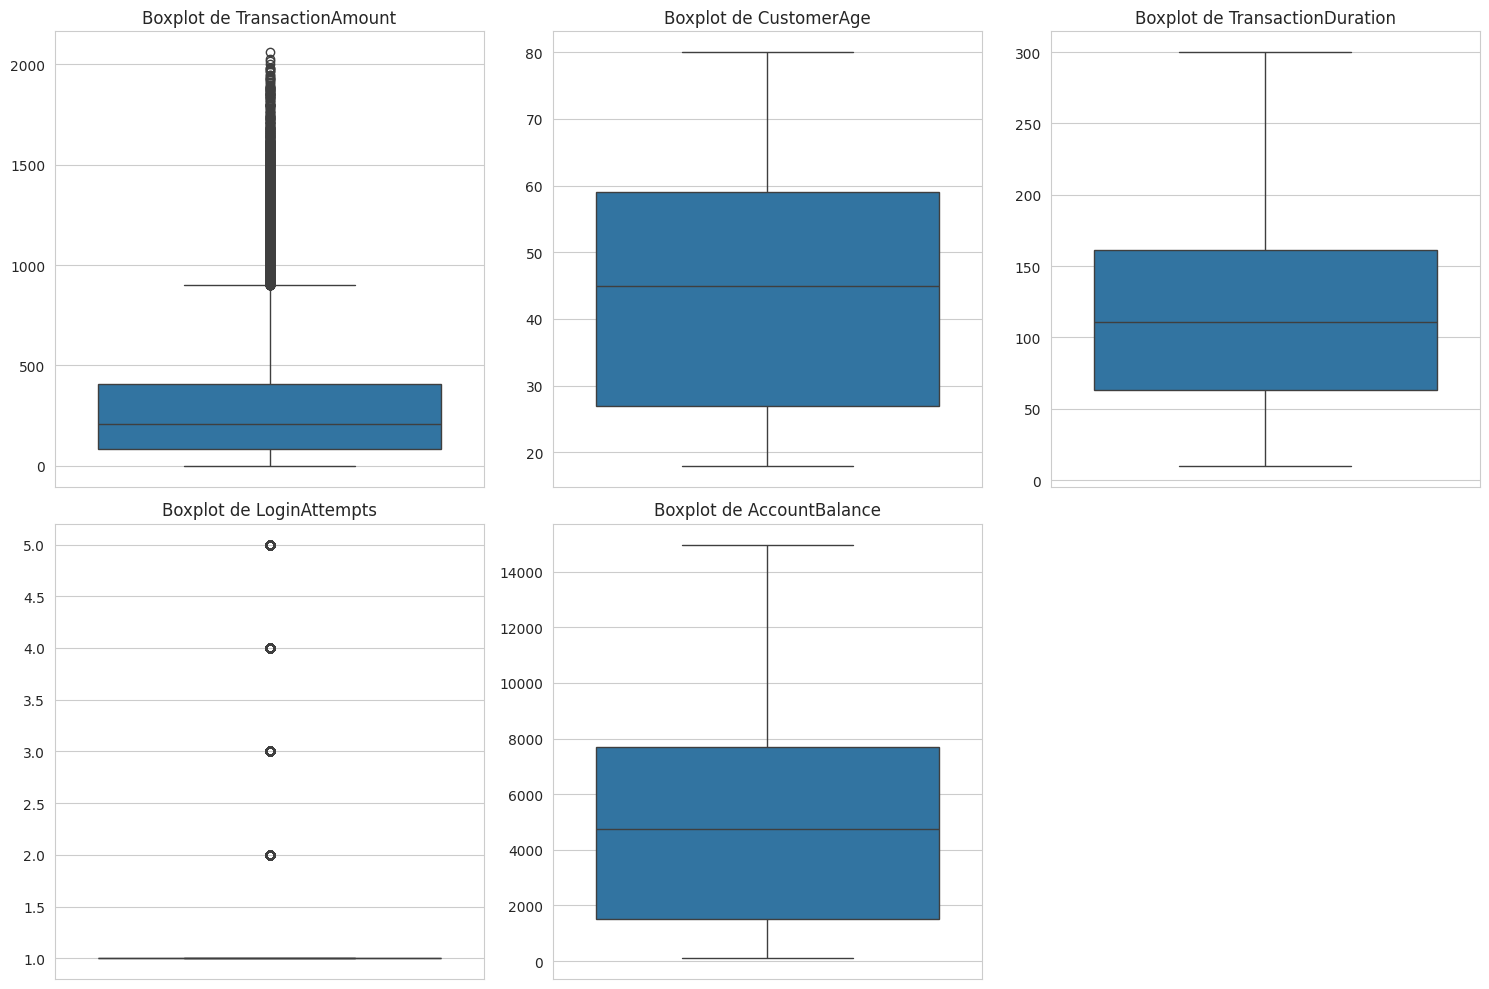

In [109]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

print("Análisis de Outliers (Valores Atípicos) por columna numérica (método IQR):\n")

# Calcular Q1, Q3 e IQR para cada columna numérica
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

# Definir límites para outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identificar outliers para cada columna
outliers_summary = pd.DataFrame(index=numeric_df.columns, columns=['Lower Bound', 'Upper Bound', 'Outliers Count'])

for col in numeric_df.columns:
    col_outliers = numeric_df[(numeric_df[col] < lower_bound[col]) | (numeric_df[col] > upper_bound[col])]
    outliers_summary.loc[col, 'Lower Bound'] = lower_bound[col]
    outliers_summary.loc[col, 'Upper Bound'] = upper_bound[col]
    outliers_summary.loc[col, 'Outliers Count'] = len(col_outliers)

display(outliers_summary)

print("\nVisualización de Outliers con Boxplots:")

# Generar boxplots para cada columna numérica
plt.figure(figsize=(15, 10))
for i, column in enumerate(numeric_df.columns):
    plt.subplot(2, 3, i + 1) # Ajusta el grid si tienes más columnas
    sns.boxplot(y=df[column])
    plt.title(f'Boxplot de {column}')
    plt.ylabel('')
plt.tight_layout()
plt.show()


## Análisis de Valores Nulos

### ¿Qué hace este bloque?
Este bloque identifica y cuantifica la presencia de valores nulos (faltantes) en cada columna del DataFrame.

### ¿Por qué es importante?
Los valores nulos pueden afectar la calidad de nuestro análisis y el rendimiento de futuros modelos de machine learning. Entender su distribución nos permite decidir cómo manejarlos: si imputarlos, eliminarlos o dejarlos tal cual si son significativos.

### Explicación del código
- `df.isnull().sum()`: Cuenta el número de valores nulos por cada columna.
- `df.isnull().sum() / len(df) * 100`: Calcula el porcentaje de valores nulos respecto al total de filas para cada columna, lo que facilita la visualización de la proporción de datos faltantes.

### ¿Qué deberías observar aquí?
- Columnas con un alto porcentaje de nulos pueden requerir estrategias de imputación o consideración para ser eliminadas.
- Columnas sin nulos (como en este caso) confirman que el dataset está limpio en este aspecto, o que los nulos fueron manejados en una etapa previa.

In [108]:
print("Porcentaje de valores nulos por columna:")
null_percentages = df.isnull().sum() / len(df) * 100
display(null_percentages[null_percentages > 0].sort_values(ascending=False))

if null_percentages.sum() == 0:
    print("¡El dataset no contiene valores nulos en ninguna columna!\n")
else:
    print("Columnas con valores nulos (mostrando solo las que tienen nulos):\n")

Porcentaje de valores nulos por columna:


,0


¡El dataset no contiene valores nulos en ninguna columna!



### Interpretación del Análisis de Nulos

En este caso particular, el resultado del código indica que el dataset no contiene valores nulos. Esto simplifica las fases posteriores de preprocesamiento, ya que no será necesario aplicar técnicas de imputación o eliminación de filas/columnas por datos faltantes.